# Seaborn Data Visualization
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Seaborn is a statistical data visualization library built on top of Matplotlib. While Matplotlib gives you fine-grained control, Seaborn provides **high-level, publication-quality** plots with minimal code — especially for exploring relationships in tabular (Pandas) data. It handles grouping, error bars, color palettes, and multi-panel layouts automatically.

In movement neuroscience, Seaborn is ideal for visualizing reaction-time distributions across conditions, overlaying individual data points on bar charts (a best practice in modern reporting), exploring correlations between biomechanical variables, and building multi-panel summary figures.

**Prerequisites:** Python Basics (L0), NumPy (L1), Matplotlib (L4), Pandas (L5).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.  
**Reference:** [Seaborn Example Gallery](https://seaborn.pydata.org/examples/index.html)

---

## Table of Contents

**Part I — Core Plot Types**
1. [Line Plot](#1)
2. [Bar Plot (Categorical)](#2)
3. [Box Plot](#3)
4. [Violin Plot](#4)

**Part II — Regression & Joint Distributions**
5. [Linear Regression with `lmplot`](#5)
6. [Joint Plot — Regression with Marginals](#6)

**Part III — Bar Charts with Individual Data Points**
7. [Bar + Swarm Overlay](#7)
8. [Bar + Strip with Grouped Hue](#8)
9. [Error Bars with Caps](#9)

**Part IV — Advanced Visualizations**
10. [Bivariate Scatter with KDE Contours](#10)
11. [Paired Categorical Plots (PairGrid)](#11)
12. [Kernel Density with Marginal Histograms](#12)
13. [Scatterplot Matrix (Pairplot)](#13)
14. [3-D Plots with Fitted Planes](#14)
15. [Heatmaps and Clustermaps](#15)

**Part V — Practice**
16. [Exercises](#16)
17. [Summary & Further Reading](#17)

In [2]:
# ---- Setup: import all libraries we'll use ----

import seaborn as sns               # High-level statistical visualization
import matplotlib.pyplot as plt      # Low-level plotting (Seaborn is built on this)
import numpy as np                   # Numerical arrays
import pandas as pd                  # Tabular data
import statsmodels.formula.api as smf  # For OLS regression (used in 3D plot)
from mpl_toolkits import mplot3d      # For 3D plotting

---
# Part I — Core Plot Types

Seaborn comes with several built-in example datasets (tips, penguins, fmri, titanic, iris, etc.) that are perfect for learning. We'll use these throughout.

## 1. Line Plot <a id='1'></a>

`sns.lineplot()` is ideal for time-series data. It automatically computes the **mean and confidence interval** when there are multiple observations per time point.

**Neuroscience use:** Plotting averaged fMRI/EEG/EMG signals across conditions, with shaded error bands.

Shape: (1064, 5)
  subject  timepoint event    region    signal
0     s13         18  stim  parietal -0.017552
1      s5         14  stim  parietal -0.080883
2     s12         18  stim  parietal -0.081033
3     s11         18  stim  parietal -0.046134
4     s10         18  stim  parietal -0.037970


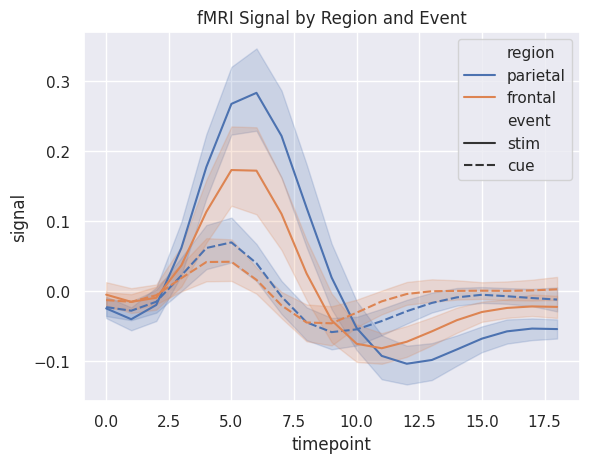

In [3]:
# ---- Line plot with automatic CI shading ----
# The fmri dataset has repeated measurements across subjects.
# Seaborn automatically computes mean ± 95% CI and shades the band.

sns.set_theme(style="darkgrid")

fmri = sns.load_dataset("fmri")       # Built-in example dataset
print(f"Shape: {fmri.shape}")
print(fmri.head())

# hue = separate lines by 'region', style = different line styles by 'event'
sns.lineplot(x="timepoint", y="signal",
             hue="region", style="event",
             data=fmri)
plt.title("fMRI Signal by Region and Event")
plt.show()

---
## 2. Bar Plot (Categorical) <a id='2'></a>

`sns.catplot(kind="bar")` creates grouped bar charts with automatic error bars. The `hue` parameter adds a second grouping variable.

**Neuroscience use:** Comparing mean body mass (or any measure) across species/conditions, split by sex/group.

Shape: (344, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


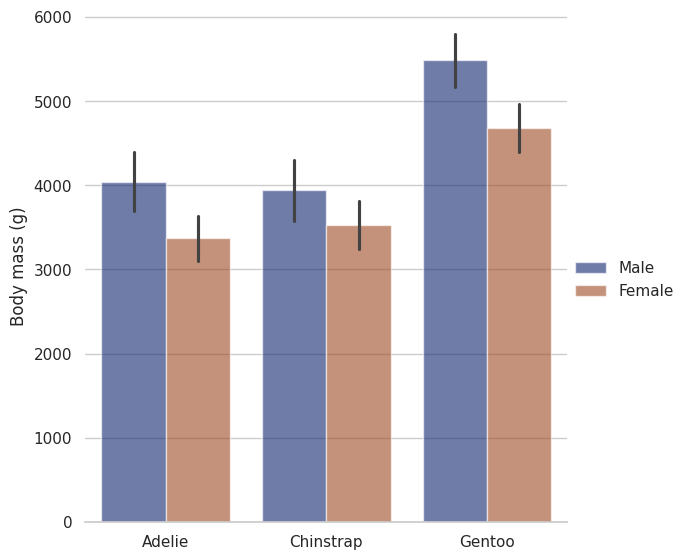

In [4]:
# ---- Grouped bar plot with error bars ----

sns.set_theme(style="whitegrid")

penguins = sns.load_dataset("penguins")
print(f"Shape: {penguins.shape}")
print(penguins.head())

g = sns.catplot(
    data=penguins, kind="bar",
    x="species", y="body_mass_g", hue="sex",  # Group by species, color by sex
    errorbar="sd",        # Show standard deviation as error bars
    palette="dark",       # Color palette
    alpha=0.6,            # Transparency
    height=6
)
g.despine(left=True)
g.set_axis_labels("", "Body mass (g)")
g.legend.set_title("")
plt.show()

---
## 3. Box Plot <a id='3'></a>

`sns.boxplot()` shows the distribution of data through quartiles, with whiskers extending to show the range (and outliers beyond).

**Neuroscience use:** Comparing the spread of reaction times or endpoint errors across conditions/groups.

Shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


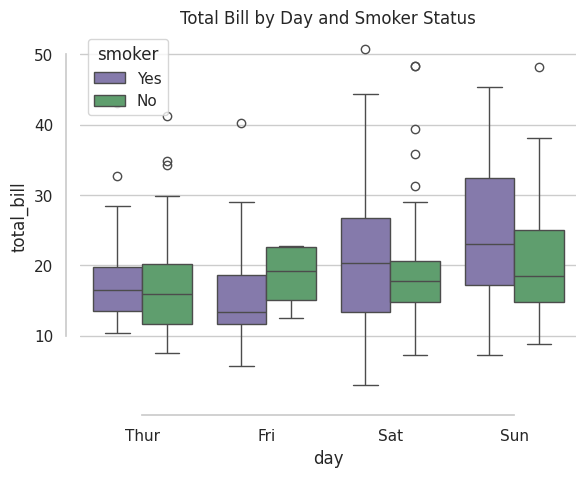

In [5]:
# ---- Nested box plot: bills grouped by day, colored by smoker status ----

tips = sns.load_dataset("tips")
print(f"Shape: {tips.shape}")
print(tips.head())

sns.boxplot(x="day", y="total_bill",
            hue="smoker",              # Split boxes by smoker status
            palette=["m", "g"],        # Magenta and green
            data=tips)
sns.despine(offset=10, trim=True)       # Clean up the axes
plt.title("Total Bill by Day and Smoker Status")
plt.show()

---
## 4. Violin Plot <a id='4'></a>

`sns.violinplot()` combines a box plot with a kernel density estimate, showing the full distribution shape. The `split=True` option puts both groups side-by-side in the same violin.

**Neuroscience use:** Showing the full distribution of movement durations or force magnitudes across conditions — more informative than a box plot alone.

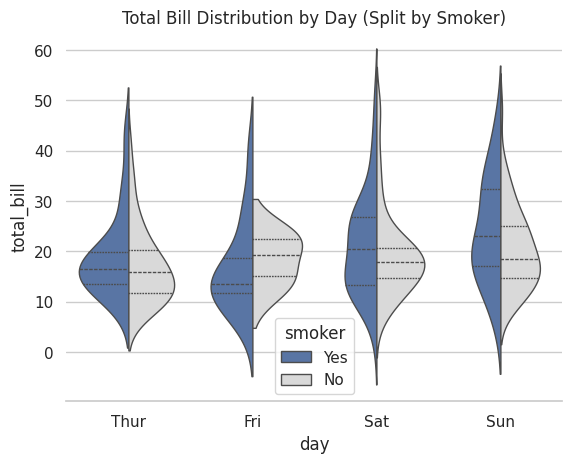

In [6]:
# ---- Split violin plot: compare distributions side by side ----

sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker",
               split=True,               # Put both hue levels in one violin
               inner="quart",             # Show quartile lines inside
               linewidth=1,
               palette={"Yes": "b", "No": ".85"})
sns.despine(left=True)
plt.title("Total Bill Distribution by Day (Split by Smoker)")
plt.show()

---
# Part II — Regression & Joint Distributions

## 5. Linear Regression with `lmplot` <a id='5'></a>

`sns.lmplot()` fits and plots a linear regression model, automatically separated by a grouping variable (`hue`). It draws the regression line with a confidence band.

**Neuroscience use:** Visualizing the relationship between bill length and depth (or joint angle vs. torque) across species/conditions.

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


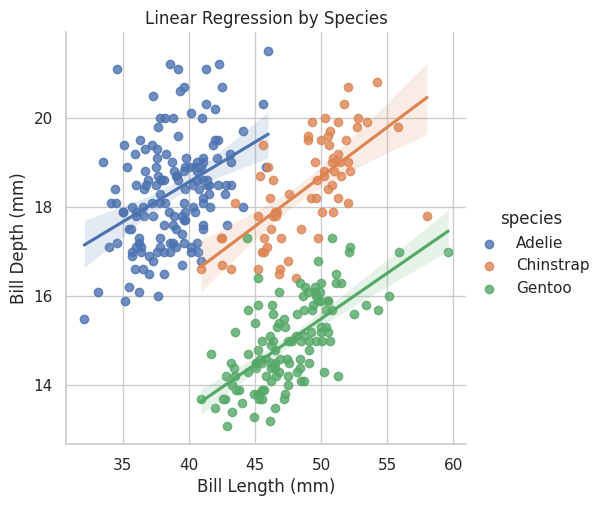

In [7]:
# ---- Linear regression by species ----

print(penguins.head())

g = sns.lmplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm",
    hue="species",      # Separate regression lines per species
    height=5
)
g.set_axis_labels("Bill Length (mm)", "Bill Depth (mm)")
plt.title("Linear Regression by Species")
plt.show()

---
## 6. Joint Plot — Regression with Marginals <a id='6'></a>

`sns.jointplot()` combines a central scatter/regression plot with marginal histograms or KDEs on each axis. A powerful way to see both the bivariate relationship and univariate distributions.

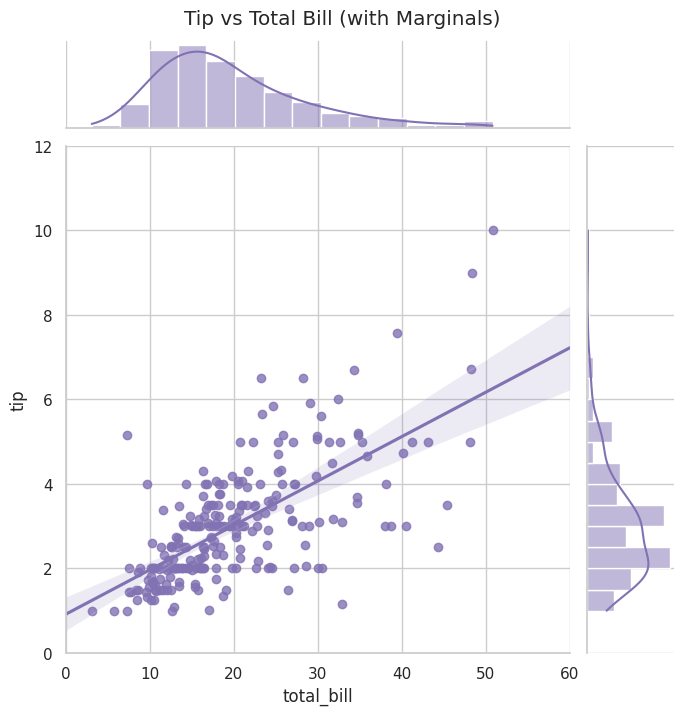

In [8]:
# ---- Joint plot: regression + marginal distributions ----

g = sns.jointplot(x="total_bill", y="tip", data=tips,
                  kind="reg",              # Regression line in center
                  truncate=False,
                  xlim=(0, 60), ylim=(0, 12),
                  color="m",               # Magenta
                  height=7)
plt.suptitle("Tip vs Total Bill (with Marginals)", y=1.02)
plt.show()

---
# Part III — Bar Charts with Individual Data Points

Modern scientific reporting increasingly requires showing **individual data points** alongside summary bars. Seaborn makes this easy by layering `swarmplot` or `stripplot` on top of `barplot`.

## 7. Bar + Swarm Overlay <a id='7'></a>

A **swarm plot** arranges non-overlapping points so every observation is visible.

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


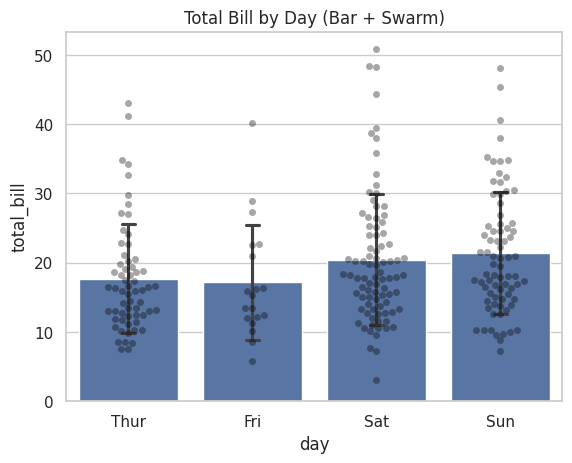

In [9]:
# ---- Bar chart with individual data points (swarmplot) ----
# This is the gold standard for modern scientific figures.

sns.set_theme(style="whitegrid")

print(tips.head())

sns.barplot(x="day", y="total_bill", data=tips,
            capsize=0.1,              # Add caps to error bars
            errorbar="sd")            # Standard deviation error bars

sns.swarmplot(x="day", y="total_bill", data=tips,
              color="0",              # Black dots
              alpha=0.35)             # Semi-transparent

plt.title("Total Bill by Day (Bar + Swarm)")
plt.show()

---
## 8. Bar + Strip with Grouped Hue <a id='8'></a>

When you have a `hue` grouping, use `stripplot` with `dodge=True` to align the dots with their corresponding bars.

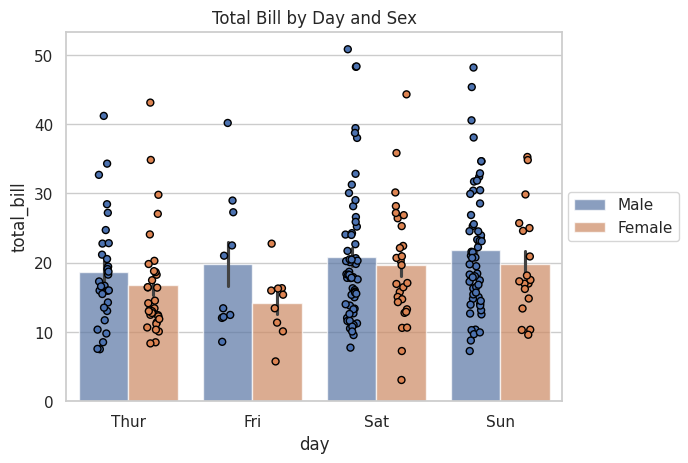

In [10]:
# ---- Grouped bar + strip plot with separate legend ----

# Draw the bars
ax = sns.barplot(data=tips, x="day", y="total_bill", hue="sex",
                 alpha=0.7,
                 errorbar="se")       # Standard error bars

# Save the bar legend before stripplot adds extra handles
handles, labels = ax.get_legend_handles_labels()

# Overlay individual points (dodge=True aligns with bars)
sns.stripplot(data=tips, x="day", y="total_bill", hue="sex",
              dodge=True,
              edgecolor="black", linewidth=1.0,
              ax=ax)

# Clean up the legend (remove duplicate strip entries)
ax.legend_.remove()
ax.legend(handles, labels, loc=7, bbox_to_anchor=(1.25, 0.5))
plt.title("Total Bill by Day and Sex")
plt.show()

---
## 9. Error Bars with Caps <a id='9'></a>

You can fine-tune error bar appearance with `errcolor`, `errwidth`, and `capsize`.

/tmp/ipykernel_177/2636521051.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  ax = sns.barplot(x="sex", y="total_bill", hue="smoker", data=tips,
/tmp/ipykernel_177/2636521051.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(x="sex", y="total_bill", hue="smoker", data=tips,


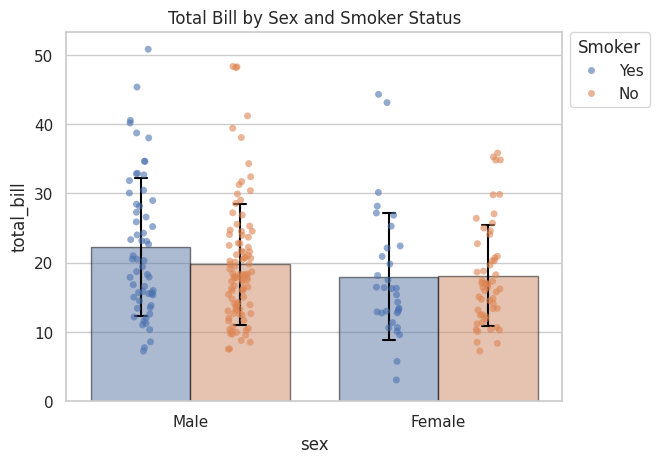

In [11]:
# ---- Polished bar + strip with custom error bars ----

ax = sns.barplot(x="sex", y="total_bill", hue="smoker", data=tips,
                 errorbar="sd",
                 edgecolor="black",     # Black bar edges
                 errcolor="black",       # Black error bar lines
                 errwidth=1.5,           # Error bar line thickness
                 capsize=0.1,            # Cap width
                 alpha=0.5)              # Semi-transparent bars

sns.stripplot(x="sex", y="total_bill", hue="smoker", data=tips,
              dodge=True, alpha=0.6, ax=ax)

# Clean up legend (keep only bar handles, not strip duplicates)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[2:], labels[2:], title='Smoker',
          bbox_to_anchor=(1, 1.02), loc='upper left')
plt.title("Total Bill by Sex and Smoker Status")
plt.show()

---
# Part IV — Advanced Visualizations

## 10. Bivariate Scatter with KDE Contours <a id='10'></a>

Combine `scatterplot`, `histplot` (2-D), and `kdeplot` on the same axes to show a bivariate distribution from multiple angles simultaneously.

**Neuroscience use:** Visualizing the joint distribution of two kinematic variables (e.g., peak velocity vs. movement duration).

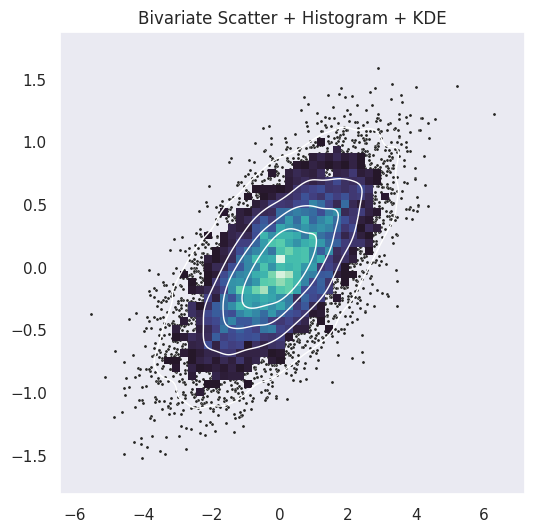

In [12]:
# ---- Bivariate scatter + histogram + KDE contours ----

sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, 0.4), (0.4, 0.2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")          # Tiny gray dots
sns.histplot(x=x, y=y, bins=50, pthresh=0.1,
             cmap="mako")                               # 2-D histogram
sns.kdeplot(x=x, y=y, levels=5, color="w",
            linewidths=1)                               # White KDE contours
plt.title("Bivariate Scatter + Histogram + KDE")
plt.show()

---
## 11. Paired Categorical Plots (PairGrid) <a id='11'></a>

`sns.PairGrid` lets you map a plot function across a grid of variable pairs. Combined with `pointplot`, it's great for comparing a response across multiple categorical predictors.

**Neuroscience use:** Comparing survival/success rates (or accuracy) across multiple categorical factors simultaneously.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 4}` instead.

  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_k

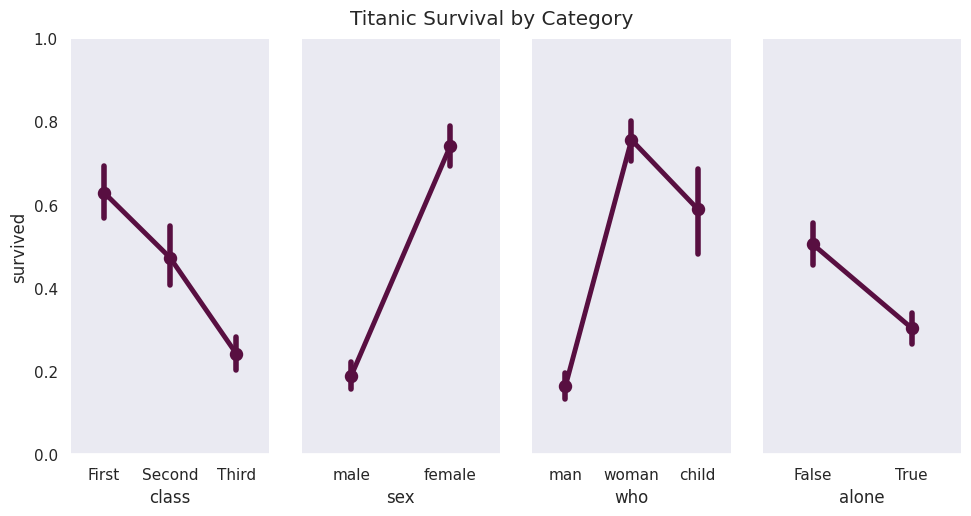

In [13]:
# ---- PairGrid: survival probability vs multiple variables ----

titanic = sns.load_dataset("titanic")

g = sns.PairGrid(titanic,
                 y_vars="survived",
                 x_vars=["class", "sex", "who", "alone"],
                 height=5, aspect=0.5)

g.map(sns.pointplot, scale=1.3, errwidth=4, color="xkcd:plum")
g.set(ylim=(0, 1))
sns.despine(fig=g.fig, left=True)
plt.suptitle("Titanic Survival by Category", y=1.02)
plt.show()

---
## 12. Kernel Density with Marginal Histograms <a id='12'></a>

`sns.JointGrid` gives you full control over the center plot and marginal plots. Here we use a filled KDE in the center and histograms on the margins.

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


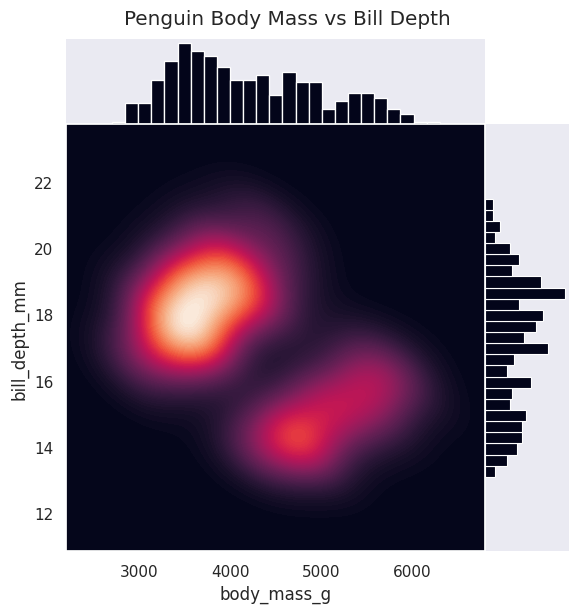

In [14]:
# ---- JointGrid: KDE center + histogram margins ----

df = sns.load_dataset("penguins")
print(df.head())

g = sns.JointGrid(data=df, x="body_mass_g", y="bill_depth_mm", space=0)

g.plot_joint(sns.kdeplot,
             fill=True,
             clip=((2200, 6800), (10, 25)),  # Clip to data range
             thresh=0,                        # Show all density levels
             levels=100,
             cmap="rocket")

g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
plt.suptitle("Penguin Body Mass vs Bill Depth", y=1.02)
plt.show()

---
## 13. Scatterplot Matrix (Pairplot) <a id='13'></a>

`sns.pairplot()` creates a matrix of scatter plots for all pairs of numerical variables, with histograms on the diagonal. Colored by a grouping variable, it gives you an instant overview of your entire dataset.

**Neuroscience use:** Exploring relationships among all kinematic/kinetic variables at once, colored by condition.

Shape: (344, 7)


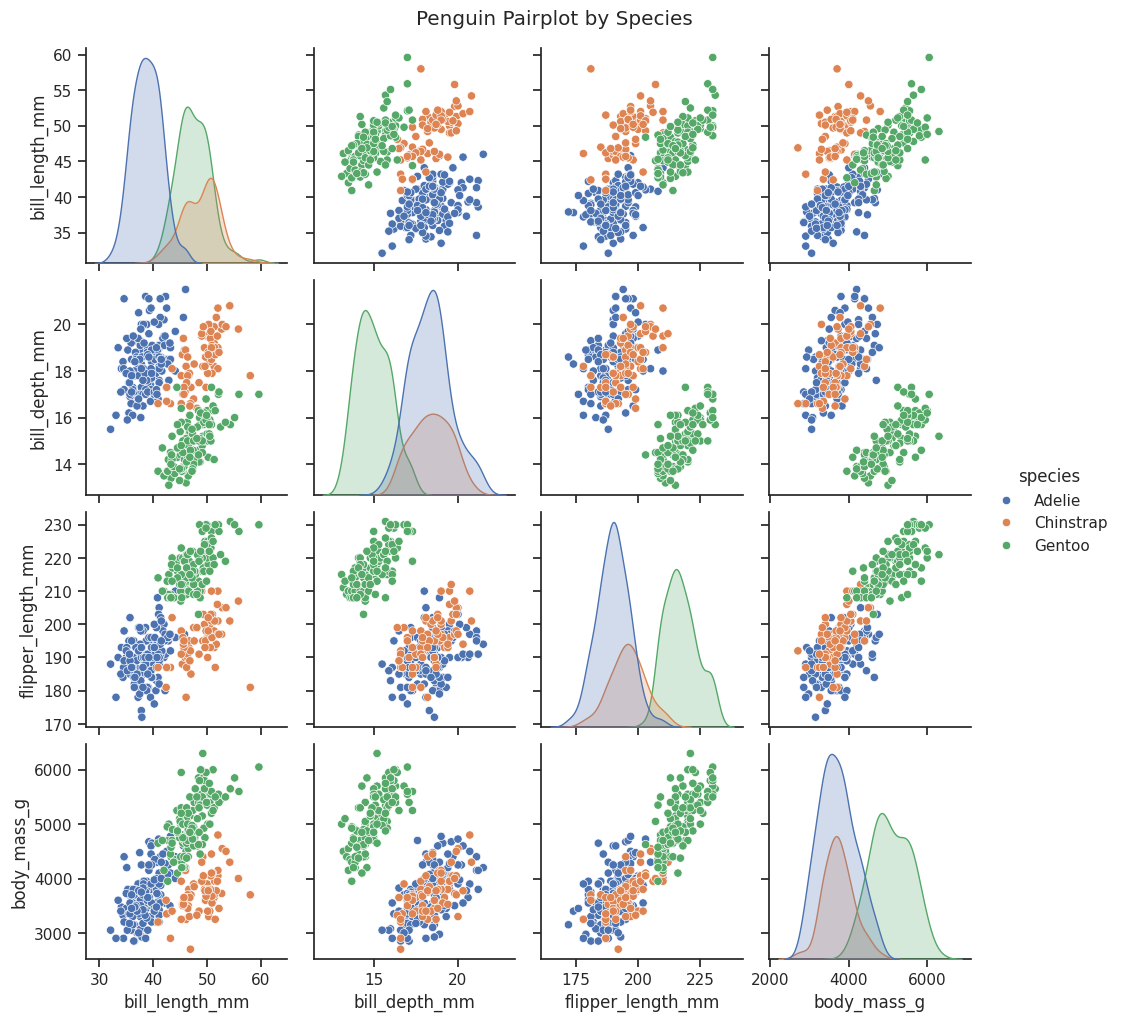

In [15]:
# ---- Pairplot: scatterplot matrix colored by species ----

sns.set_theme(style="ticks")
print(f"Shape: {df.shape}")

sns.pairplot(df, hue="species")  # One line for an entire exploration!
plt.suptitle("Penguin Pairplot by Species", y=1.02)
plt.show()

---
## 14. 3-D Plots with Fitted Planes <a id='14'></a>

Seaborn doesn't natively support 3-D plots, but we can combine `statsmodels` for regression with Matplotlib's `mplot3d` to create 3-D scatter plots with fitted regression planes.

**Neuroscience use:** Visualizing how a response variable (e.g., movement time) depends on two predictors simultaneously (e.g., target distance and load).

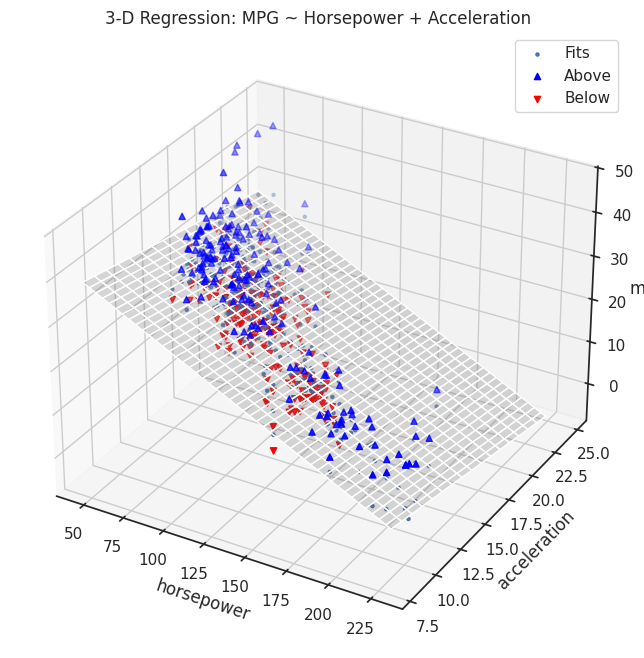

In [16]:
# ---- 3-D scatter + fitted regression plane ----

df_mpg = sns.load_dataset('mpg')
df_mpg.dropna(inplace=True)

# Fit a multiple linear regression: mpg ~ horsepower + acceleration
model = smf.ols(formula='mpg ~ horsepower + acceleration', data=df_mpg)
results = model.fit()

# Extract predictor names
x_name, y_name = model.exog_names[1:]  # 'horsepower', 'acceleration'

# Create a mesh grid for the fitted plane
x_range = np.arange(df_mpg[x_name].min(), df_mpg[x_name].max())
y_range = np.arange(df_mpg[y_name].min(), df_mpg[y_name].max())
X, Y = np.meshgrid(x_range, y_range)

# Predict on the grid
exog = pd.DataFrame({x_name: X.ravel(), y_name: Y.ravel()})
Z = results.predict(exog=exog).values.reshape(X.shape)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

# Fitted values as dots
ax.scatter(df_mpg[x_name].values, df_mpg[y_name].values,
           results.fittedvalues.values, marker='.', label="Fits")

# Color residuals: above plane = blue, below = red
above = df_mpg['mpg'].values > results.fittedvalues.values
ax.scatter(df_mpg[x_name][above].values, df_mpg[y_name][above].values,
           df_mpg['mpg'][above].values, color='blue', marker='^', label='Above')
ax.scatter(df_mpg[x_name][~above].values, df_mpg[y_name][~above].values,
           df_mpg['mpg'][~above].values, color='red', marker='v', label='Below')

# Fitted plane surface
ax.plot_surface(X, Y, Z, alpha=0.2, color='grey')

ax.set_xlabel(x_name)
ax.set_ylabel(y_name)
ax.set_zlabel('mpg')
ax.legend()
plt.title('3-D Regression: MPG ~ Horsepower + Acceleration')
plt.show()

---
## 15. Heatmaps and Clustermaps <a id='15'></a>

**Heatmaps** display matrix data as colors. **Clustermaps** add hierarchical clustering to reorder rows and columns, revealing structure.

**Neuroscience use:** Correlation matrices between muscles, time-frequency spectrograms, or muscle synergy weight matrices.

In [17]:
# ---- Load the iris dataset for clustering ----

iris_data = sns.load_dataset("iris")
print(iris_data.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


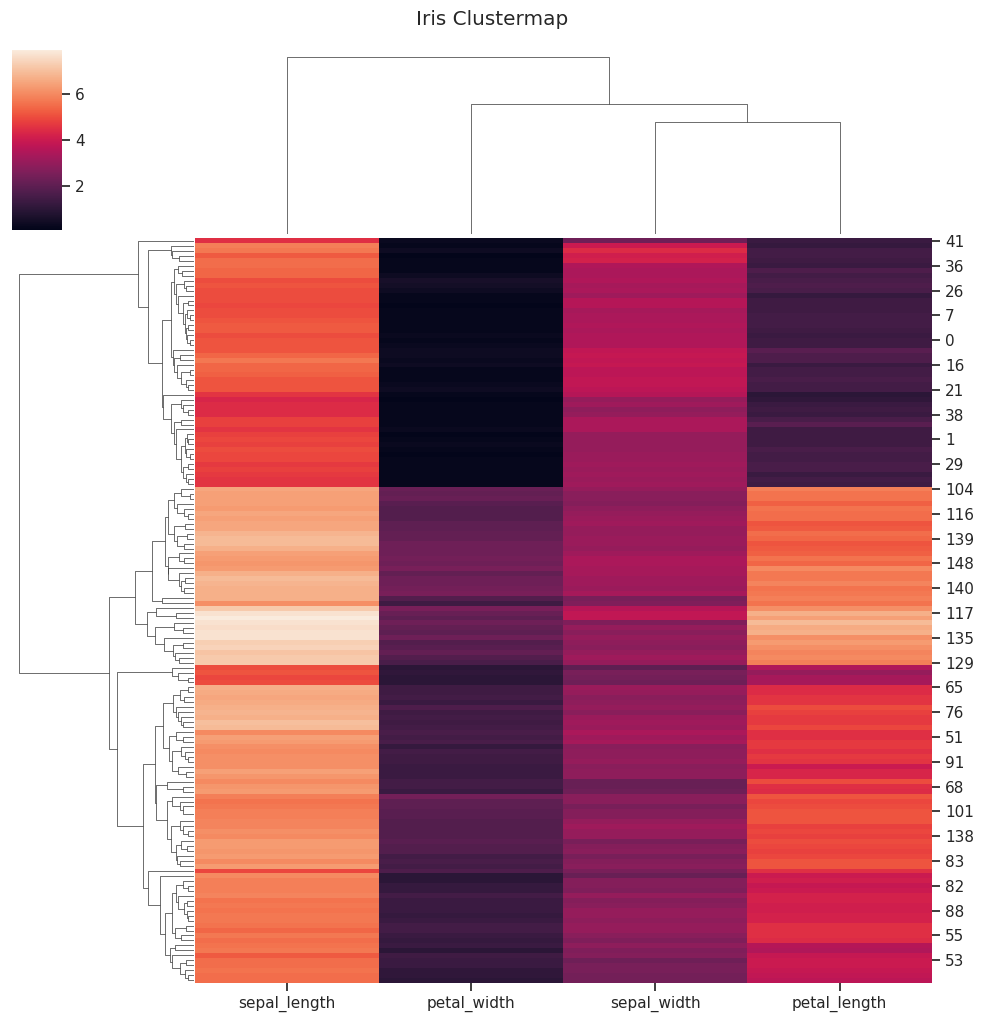

In [18]:
# ---- Clustermap: hierarchical clustering with a heatmap ----
# Rows and columns are reordered by similarity.

sns.clustermap(iris_data.drop("species", axis=1))  # Drop the categorical column
plt.suptitle("Iris Clustermap", y=1.02)
plt.show()

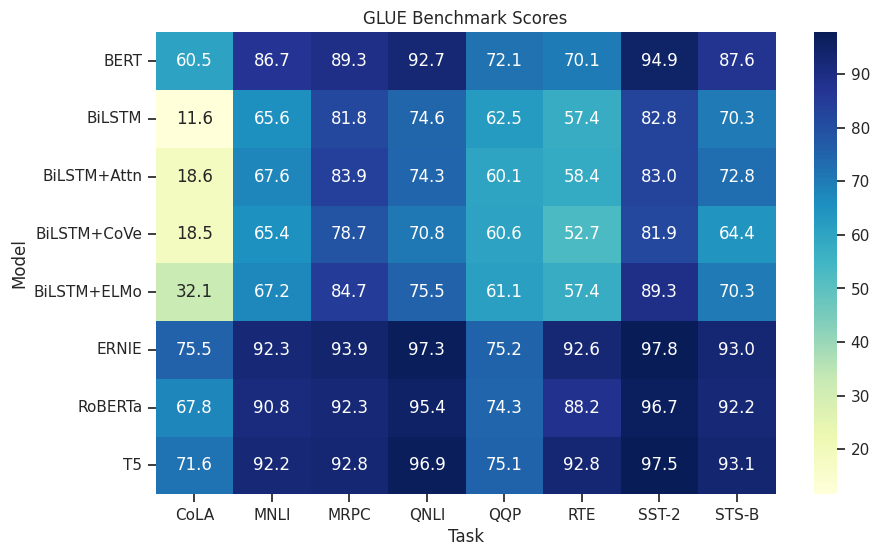

In [19]:
# ---- Heatmap: visualize a pivot table ----

glue = sns.load_dataset("glue").pivot(
    index="Model", columns="Task", values="Score")

plt.figure(figsize=(10, 6))
sns.heatmap(glue, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("GLUE Benchmark Scores")
plt.show()

---
# Part V — Practice

## 16. Exercises <a id='16'></a>

---

### Exercise 1: Violin Plot of Reaction Times

Generate synthetic RT data for 3 conditions and create a split violin plot:
```python
rng = np.random.default_rng(42)
rt_data = pd.DataFrame({
    "condition": ["control"]*50 + ["perturbation"]*50 + ["washout"]*50,
    "group": (["young"]*25 + ["old"]*25) * 3,
    "rt": np.concatenate([
        rng.normal(0.35, 0.04, 50),
        rng.normal(0.42, 0.06, 50),
        rng.normal(0.37, 0.05, 50)
    ])
})
```

1. Create a `sns.violinplot` with `x="condition"`, `y="rt"`, `hue="group"`, `split=True`.
2. Add axis labels and a title.

In [ ]:
# ---- YOUR CODE HERE ----

# rt_data = pd.DataFrame({...})
# sns.violinplot(...)
# plt.show()

### Exercise 2: Bar + Swarm Plot (Publication Style)

Using the same `rt_data` from Exercise 1:
1. Create a `sns.barplot` with `errorbar="sd"` and `capsize=0.1`.
2. Overlay a `sns.swarmplot` with `color="black"` and `alpha=0.4`.
3. Set the y-axis label to `"Reaction Time (s)"` and add a title.

In [ ]:
# ---- YOUR CODE HERE ----

# sns.barplot(x="condition", y="rt", data=rt_data, ...)
# sns.swarmplot(x="condition", y="rt", data=rt_data, ...)
# plt.show()

### Exercise 3: Pairplot Exploration (Challenge)

Using the penguins dataset:
1. Create a `sns.pairplot` colored by `"island"` instead of `"species"`.
2. Use `kind="reg"` to add regression lines to the scatter panels.
3. What relationships do you notice between the variables?

In [ ]:
# ---- YOUR CODE HERE ----

# penguins = sns.load_dataset("penguins")
# sns.pairplot(penguins, hue="island", kind="reg")
# plt.show()

---
## 17. Summary & Further Reading <a id='17'></a>

### What You Learned

| Plot Type | Function | Best for |
|---|---|---|
| **Line plot** | `sns.lineplot()` | Time-series with automatic CI bands |
| **Bar plot** | `sns.barplot()` / `sns.catplot(kind="bar")` | Comparing category means |
| **Box plot** | `sns.boxplot()` | Distribution quartiles, outliers |
| **Violin plot** | `sns.violinplot()` | Full distribution shape |
| **Regression** | `sns.lmplot()` | Linear fit with CI per group |
| **Joint plot** | `sns.jointplot()` | Bivariate + marginal distributions |
| **Swarm/Strip** | `sns.swarmplot()` / `sns.stripplot()` | Individual data points on bars |
| **KDE** | `sns.kdeplot()` | Smooth density contours |
| **PairGrid** | `sns.PairGrid()` | Map plots across variable pairs |
| **Pairplot** | `sns.pairplot()` | Scatterplot matrix (entire dataset) |
| **Heatmap** | `sns.heatmap()` | Matrix values as colors |
| **Clustermap** | `sns.clustermap()` | Heatmap + hierarchical clustering |

### Key Seaborn Concepts

| Concept | What it does |
|---|---|
| `hue` | Color-code by a grouping variable |
| `style` | Vary line style or marker by a variable |
| `errorbar="sd"` / `"se"` / `"ci"` | Control error bar type |
| `split=True` | Side-by-side violins |
| `dodge=True` | Align strip/swarm with grouped bars |
| `palette` | Color scheme (`"dark"`, `"muted"`, `"Set2"`, etc.) |
| `sns.set_theme(style=...)` | Global theme (`"darkgrid"`, `"whitegrid"`, `"ticks"`) |
| `sns.despine()` | Remove top/right axes for cleaner look |

### Further Reading

- [Seaborn Official Tutorial](https://seaborn.pydata.org/tutorial.html) — comprehensive guide
- [Seaborn Example Gallery](https://seaborn.pydata.org/examples/index.html) — copy-pasteable examples
- [Seaborn API Reference](https://seaborn.pydata.org/api.html) — every function documented
- [Raincloud Plots in Python](https://github.com/pog87/PtitPrince) — combining violin + box + strip (increasingly popular in neuroscience)
- [Scientific Visualization Book (free)](https://github.com/rougier/scientific-visualization-book) — advanced techniques

### What's Next?

With Seaborn and Matplotlib mastered, you're ready for:
- **SciPy** — signal processing (filtering, spectral analysis) and statistical tests
- **Statsmodels** — regression, ANOVA, mixed-effects models
- **scikit-learn** — machine learning and dimensionality reduction
- **Object-Oriented Programming** — organizing your analysis pipeline into reusable classes

---

*Happy visualizing, and may your figures always show the individual data points!*